In [ ]:
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

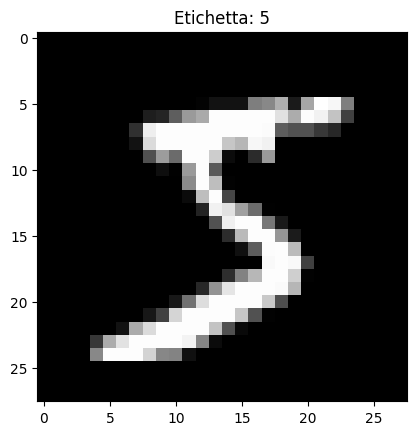

In [36]:
# Caricamento del dataset MNIST

(X_train, y_train), (X_test, y_test) = mnist.load_data()


# Visualizzazione di un esempio

plt.imshow(X_train[0], cmap='gray')

plt.title(f'Etichetta: {y_train[0]}')

plt.show()


# Normalizzazione dei dati - le reti neurali funzionano SOLO con dati normalizzati

X_train = X_train.astype('float32') / 255

X_test = X_test.astype('float32') / 255


# Reshape dei dati- per poter gestire le matrice in modo piu corretto

X_train = X_train.reshape(-1, 28*28)

X_test = X_test.reshape(-1, 28*28)


# Conversione delle etichette in formato one-hotencoding 

y_train = to_categorical(y_train, num_classes=10)

y_test = to_categorical(y_test, num_classes=10)

In [37]:
# Creazione del modello

model = Sequential()


# Aggiunta degli strati  - parto dai dati in ingresso: 28*28= 784(linearizzo le mie matrici)

model.add(Dense(units=128, activation='relu', input_shape=(784,)))  

#se ho un caso di overfitting
model.add(Dropout(0.3))

model.add(Dense(units=64, activation='relu'))  

#se ho un caso di overfitting
model.add(Dropout(0.3))

model.add(Dense(units=10, activation='softmax'))   #quello decisionale- con softmax perche ci deve restituire anche l'accuracy

C:\Users\mcvis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
opt = Adam(learning_rate=0.001)

NameError: name 'Adam' is not defined

In [ ]:
model.compile(optimizer='adam',  

                loss='categorical_crossentropy', #calcolo dell'errore

                metrics=['accuracy'])  #ciò a cui il modelolo deve puntare cioè alla massima accuracy

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Stop training if val_loss doesn't improve for 7 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# 2. Halve the Learning Rate if val_loss doesn't improve for 3 epochs
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, # Factor by which the learning rate will be reduced (0.5 = half)
    patience=3, # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-6, # Lower bound on the learning rate
    verbose=1
)






In [ ]:
history = model.fit(X_train, y_train,

                    epochs=100,

                    batch_size=64,

                    validation_split=0.1,
                    
                    callbacks=[early_stop, reduce_lr])

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8725 - loss: 0.4251 - val_accuracy: 0.9645 - val_loss: 0.1211
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9389 - loss: 0.2056 - val_accuracy: 0.9713 - val_loss: 0.0994
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9495 - loss: 0.1697 - val_accuracy: 0.9747 - val_loss: 0.0876
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9575 - loss: 0.1420 - val_accuracy: 0.9760 - val_loss: 0.0868
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9619 - loss: 0.1293 - val_accuracy: 0.9790 - val_loss: 0.0805
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9635 - loss: 0.1191 - val_accuracy: 0.9765 - val_loss: 0.0837
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9669 - loss: 0.1101 - val_accuracy: 0.9792 - val_loss: 0.0757
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9681 - loss: 0.1032 -

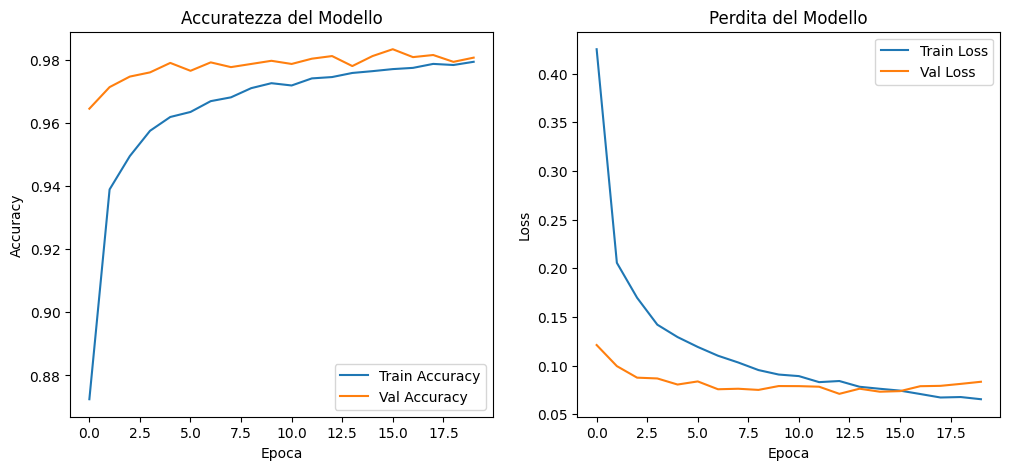

In [ ]:
import matplotlib.pyplot as plt

# Creiamo una figura con due grafici (Sottoplot)
plt.figure(figsize=(12, 5))

# Grafico della Precisione (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.xlabel('Epoca')
plt.ylabel('Accuracy')
plt.legend()

# Grafico della Perdita (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Perdita del Modello')
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f'Perdita sul test set: {test_loss:.4f}')

print(f'Accuratezza sul test set: {test_accuracy:.4f}')